# Linear Gaussian Models

This notebook studies how Gaussian beliefs evolve through linear transformations and additive Gaussian noise.

$$
\mathbf{y}=A\mathbf{x}+\mathbf{b}+\boldsymbol{\epsilon},
\qquad
\boldsymbol{\epsilon}\sim\mathcal{N}(0,Q)
$$

We will follow:

```text
Motivation
    ↓
Flowchart
    ↓
Mathematics
    ↓
Derivation
    ↓
Worked Example
    ↓
Visualization
    ↓
Implementation
    ↓
Verification
    ↓
Final Class
```


## 1. Motivation

Until now, Gaussian inference has been static. Real systems evolve: robots move, vehicles accelerate, targets change position, and sensors transform hidden states into measurements.

The core question is:

> If the current state is uncertain and the system evolves according to a model, what is the new Gaussian belief?


## 2. System-Level Flowchart

```text
Current Gaussian belief
x ~ N(μx, Σx)
        │
        ▼
Linear transformation
y = A x + b
        │
        ├── μy = A μx + b
        └── Σy = A Σx Aᵀ
        │
        ▼
Add Gaussian noise
ε ~ N(0, Q)
        │
        ▼
Final belief
y ~ N(A μx + b, A Σx Aᵀ + Q)
```


## 3. Load Existing Classes

In [17]:
%%capture
%run "./01_Gaussian_Inference_Basics.ipynb"

In [18]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


# 4. Linear Transformation of a Gaussian

If

$$
\mathbf{x}\sim\mathcal{N}(\boldsymbol{\mu}_x,\Sigma_x)
$$

and

$$
\mathbf{y}=A\mathbf{x}+\mathbf{b},
$$

then

$$
\boxed{\boldsymbol{\mu}_y=A\boldsymbol{\mu}_x+\mathbf{b}}
$$

and

$$
\boxed{\Sigma_y=A\Sigma_xA^\top}.
$$


## 4.1 Transformation Flowchart

```text
x ~ N(μx, Σx)
      │
      ▼
Apply y = A x + b
      │
      ├── A rotates / stretches / shears
      └── b shifts location
      │
      ▼
y ~ N(A μx + b, A Σx Aᵀ)
```

The offset $\mathbf{b}$ changes the mean but not the covariance.


## 4.2 Mean Derivation

$$
\mathbb{E}[\mathbf{y}]=
\mathbb{E}[A\mathbf{x}+\mathbf{b}]=
A\mathbb{E}[\mathbf{x}]+\mathbf{b}
$$

so

$$
\boxed{\boldsymbol{\mu}_y=A\boldsymbol{\mu}_x+\mathbf{b}}.
$$


## 4.3 Covariance Derivation

Because

$$
\mathbf{y}-\boldsymbol{\mu}_y=
A(\mathbf{x}-\boldsymbol{\mu}_x),
$$

$$
\Sigma_y=
\mathbb{E}\left[
A(\mathbf{x}-\boldsymbol{\mu}_x)
(\mathbf{x}-\boldsymbol{\mu}_x)^\top
A^\top
\right]
$$

and therefore

$$
\boxed{\Sigma_y=A\Sigma_xA^\top}.
$$


## 4.4 Geometric Intuition

The matrix $A$ changes the geometry of the Gaussian. It can rotate, stretch, compress, or shear the probability cloud.

That is why the covariance must transform as

$$
A\Sigma A^\top.
$$


In [19]:
belief = GaussianInference(
    mean=np.array([1.0, 2.0]),
    covariance=np.array([
        [2.0, 0.6],
        [0.6, 1.0],
    ]),
)

A = np.array([
    [1.5, 0.5],
    [-0.3, 1.2],
])

b = np.array([2.0, -1.0])

transformed_mean = A @ belief.mean + b
transformed_covariance = A @ belief.covariance @ A.T

print(transformed_mean)
print(transformed_covariance)


[4.5 1.1]
[[5.65  0.69 ]
 [0.69  1.188]]


# 5. Adding Gaussian Noise

For

$$
\mathbf{y}=
A\mathbf{x}
+
\mathbf{b}
+
\boldsymbol{\epsilon},
\qquad
\boldsymbol{\epsilon}\sim\mathcal{N}(0,Q),
$$

the mean remains

$$
\boxed{\boldsymbol{\mu}_y=A\boldsymbol{\mu}_x+\mathbf{b}}
$$

while covariance becomes

$$
\boxed{\Sigma_y=A\Sigma_xA^\top+Q}.
$$

Independent uncertainties add.


## 5.1 Noise Flowchart

```text
Transformed Gaussian
N(A μx + b, A Σx Aᵀ)
        │
        ▼
Add ε ~ N(0, Q)
        │
        ├── Mean unchanged
        └── Covariance increases by Q
        │
        ▼
Noisier Gaussian
N(A μx + b, A Σx Aᵀ + Q)
```


In [20]:
Q = np.array([
    [0.5, 0.0],
    [0.0, 0.3],
])

predicted_mean = transformed_mean
predicted_covariance = transformed_covariance + Q

print(predicted_mean)
print(predicted_covariance)


[4.5 1.1]
[[6.15  0.69 ]
 [0.69  1.488]]


## 5.2 Standalone Propagation Function

In [21]:
def propagate_linear_gaussian(
    gaussian: GaussianInference,
    A: np.ndarray,
    b: np.ndarray | None = None,
    Q: np.ndarray | None = None,
) -> GaussianInference:
    A = np.asarray(A, dtype=float)

    if A.ndim != 2:
        raise ValueError("A must be two-dimensional.")

    if A.shape[1] != gaussian.dimension:
        raise ValueError("A has incompatible input dimension.")

    output_dimension = A.shape[0]

    if b is None:
        b = np.zeros(output_dimension)
    else:
        b = np.asarray(b, dtype=float)

    if Q is None:
        Q = np.zeros((output_dimension, output_dimension))
    else:
        Q = np.asarray(Q, dtype=float)

    mean = A @ gaussian.mean + b
    covariance = A @ gaussian.covariance @ A.T + Q

    return GaussianInference(
        mean=mean,
        covariance=covariance,
    )


# 6. Complete Propagation Flowchart

```text
Current state belief
x ~ N(μx, Σx)
        │
        ▼
Apply deterministic model
A x + b
        │
        ├── Mean → A μx + b
        └── Covariance → A Σx Aᵀ
        │
        ▼
Add model uncertainty
Q
        │
        ▼
Predicted belief
N(A μx + b, A Σx Aᵀ + Q)
```


# 7. Monte Carlo Verification

In [22]:
n_samples = 100_000

x_samples = belief.sample(
    n_samples=n_samples,
    rng=rng,
)

noise_samples = rng.multivariate_normal(
    mean=np.zeros(2),
    cov=Q,
    size=n_samples,
)

y_samples = x_samples @ A.T + b + noise_samples

print("Analytical mean:")
print(predicted_mean)

print("\nEmpirical mean:")
print(y_samples.mean(axis=0))

print("\nAnalytical covariance:")
print(predicted_covariance)

print("\nEmpirical covariance:")
print(np.cov(y_samples, rowvar=False))


Analytical mean:
[4.5 1.1]

Empirical mean:
[4.50533263 1.10225262]

Analytical covariance:
[[6.15  0.69 ]
 [0.69  1.488]]

Empirical covariance:
[[6.13742104 0.69941279]
 [0.69941279 1.50153717]]


# 8. Visualization

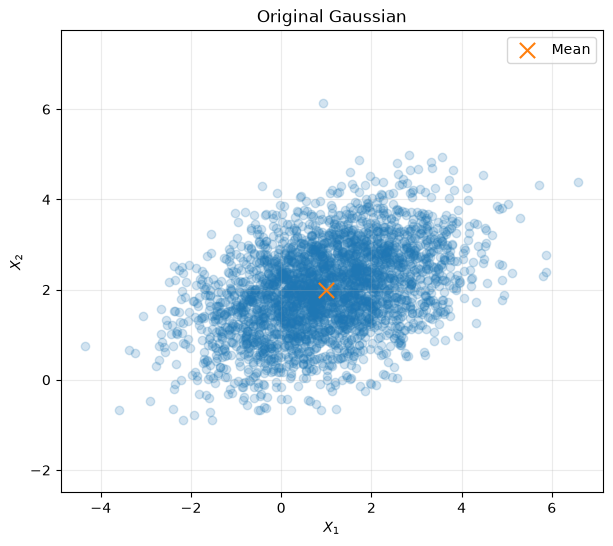

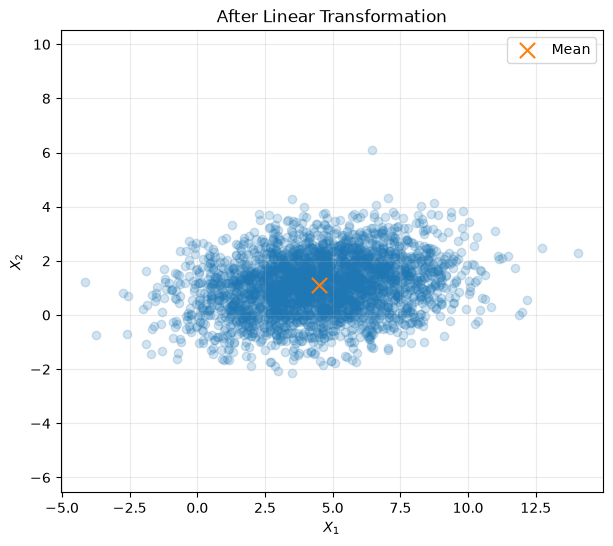

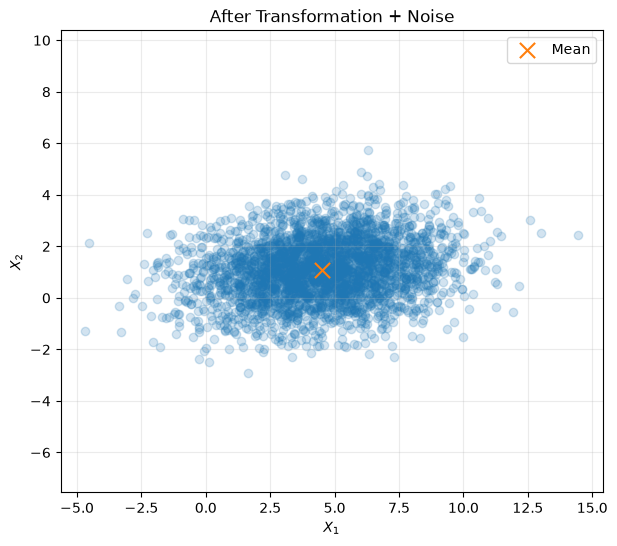

In [23]:
original_samples = belief.sample(
    n_samples=3000,
    rng=rng,
)

transformed_samples = original_samples @ A.T + b

noisy_samples = transformed_samples + rng.multivariate_normal(
    mean=np.zeros(2),
    cov=Q,
    size=3000,
)

for title, data, mean in [
    ("Original Gaussian", original_samples, belief.mean),
    ("After Linear Transformation", transformed_samples, transformed_mean),
    ("After Transformation + Noise", noisy_samples, predicted_mean),
]:
    plt.figure(figsize=(7, 6))
    plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
    plt.scatter(
        mean[0],
        mean[1],
        marker="x",
        s=120,
        label="Mean",
    )
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


# 9. Final Class

```text
Gaussian
   ↓
GaussianInference
   ↓
LinearGaussianModel
```


In [24]:
class LinearGaussianModel(GaussianInference):
    """Gaussian belief with linear propagation operations."""

    def affine_transform(
        self,
        A: np.ndarray,
        b: np.ndarray | None = None,
    ) -> "LinearGaussianModel":
        A = np.asarray(A, dtype=float)

        if A.ndim != 2:
            raise ValueError("A must be two-dimensional.")

        if A.shape[1] != self.dimension:
            raise ValueError("A has incompatible input dimension.")

        output_dimension = A.shape[0]

        if b is None:
            b = np.zeros(output_dimension)
        else:
            b = np.asarray(b, dtype=float)

        mean = A @ self.mean + b
        covariance = A @ self.covariance @ A.T

        return LinearGaussianModel(
            mean=mean,
            covariance=covariance,
        )

    def add_noise(
        self,
        Q: np.ndarray,
    ) -> "LinearGaussianModel":
        Q = np.asarray(Q, dtype=float)

        if Q.shape != self.covariance.shape:
            raise ValueError("Q must match covariance shape.")

        return LinearGaussianModel(
            mean=self.mean.copy(),
            covariance=self.covariance + Q,
        )

    def propagate(
        self,
        A: np.ndarray,
        b: np.ndarray | None = None,
        Q: np.ndarray | None = None,
    ) -> "LinearGaussianModel":
        A = np.asarray(A, dtype=float)

        if A.ndim != 2:
            raise ValueError("A must be two-dimensional.")

        if A.shape[1] != self.dimension:
            raise ValueError("A has incompatible input dimension.")

        output_dimension = A.shape[0]

        if b is None:
            b = np.zeros(output_dimension)
        else:
            b = np.asarray(b, dtype=float)

        if Q is None:
            Q = np.zeros((output_dimension, output_dimension))
        else:
            Q = np.asarray(Q, dtype=float)

        mean = A @ self.mean + b
        covariance = A @ self.covariance @ A.T + Q

        return LinearGaussianModel(
            mean=mean,
            covariance=covariance,
        )


# 10. Final Test

In [25]:
state = LinearGaussianModel(
    mean=np.array([1.0, 2.0]),
    covariance=np.array([
        [2.0, 0.6],
        [0.6, 1.0],
    ]),
)

predicted = state.propagate(
    A=A,
    b=b,
    Q=Q,
)

print(predicted)


LinearGaussianModel(mean=array([4.5, 1.1]), covariance=array([[6.15 , 0.69 ],
       [0.69 , 1.488]]))


# 11. Summary

For

$$
\mathbf{x}
\sim
\mathcal{N}(\boldsymbol{\mu}_x,\Sigma_x)
$$

and

$$
\mathbf{y}=
A\mathbf{x}
+
\mathbf{b}
+
\boldsymbol{\epsilon},
$$

we obtain

$$
\boxed{
\boldsymbol{\mu}_y=
A\boldsymbol{\mu}_x+\mathbf{b}
}
$$

and

$$
\boxed{
\Sigma_y=
A\Sigma_xA^\top+Q
}
$$

Final conceptual flow:

```text
Current belief
      │
      ▼
Apply system dynamics
      │
      ▼
Transform mean and covariance
      │
      ▼
Add process uncertainty
      │
      ▼
Predicted Gaussian belief
```

This is the mathematical foundation of the prediction step of the Kalman filter.
